In [ ]:
import numpy as np
np.random.seed(42)

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from keras.callbacks import TensorBoard
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomTranslation

In [ ]:
from tensorflow.keras.datasets import cifar100

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
model=Sequential()

# ---- Data Augmentation Block ----
model.add(RandomFlip("horizontal", input_shape=(32,32,3)))
model.add(RandomRotation(0.1))
model.add(RandomZoom(0.1))
model.add(RandomTranslation(0.1, 0.1))

# Layer 1: Convolutional (adapted for 32x32 images)
model.add(Conv2D(96, kernel_size=(3,3), strides=(1,1), activation='relu', input_shape = (32, 32, 3), padding='same'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model.add(BatchNormalization())

# Layer 2: Convolutional
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model.add(BatchNormalization())

# Layer 3: Convolutional
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'))

# Layer 4: Convolutional
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'))

# Layer 5: Convolutional
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model.add(BatchNormalization())

# Flatten layer
model.add(Flatten())

# Layer 6: Fully Connected
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Layer 7: Fully Connected
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(100, activation='softmax')) # 100 classes for CIFAR-100

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       409,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,296,484 (142.27 MB)

 Trainable params: 37,295,268 (142.27 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
import tensorflow as tf
model.compile(loss='sparse_categorical_crossentropy', optimizer = tf.keras.optimizers.SGD(learning_rate=0.01,momentum=0.9), metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train, epochs=50, validation_data=(x_test,y_test), batch_size=32)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6383 - loss: 1.2669 - val_accuracy: 0.5553 - val_loss: 1.7119
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.6389 - loss: 1.2524 - val_accuracy: 0.5400 - val_loss: 1.7501
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.6409 - loss: 1.2295 - val_accuracy: 0.5495 - val_loss: 1.7366
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.6484 - loss: 1.2233 - val_accuracy: 0.5504 - val_loss: 1.7227
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.6553 - loss: 1.1992 - val_accuracy: 0.5498 - val_loss: 1.7515
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.6639 - loss: 1.1775 - val_accuracy: 0.5398 - val_loss: 1.7671
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.6650 - loss: 1.1539 - val_accuracy: 0.5597 - val_loss: 1.6925
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6647 -

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f'Test Accuracy: {test_accuracy * 100:.2f} %')

313/313 - 2s - 6ms/step - accuracy: 0.5897 - loss: 1.6300
Test Accuracy: 58.97 %


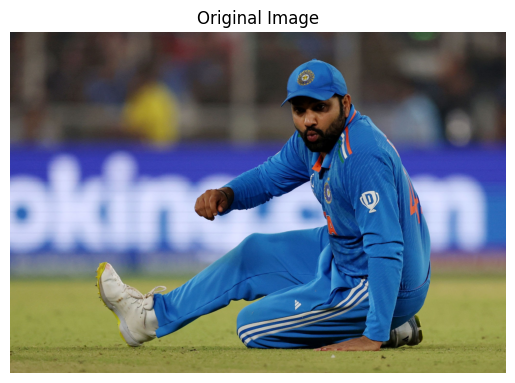

In [ ]:
import cv2
import matplotlib.pyplot as plt
img_cv=cv2.imread("sample.jpg")
img_rgb=cv2.cvtColor(img_cv,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
import keras
# from keras.models import Sequential
# from keras.layers import Dense, Dropout, Flatten
# from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
# from keras.callbacks import TensorBoard

# Preprocess the image for prediction
img_resized = cv2.resize(img_rgb, (32, 32))
img_normalized = img_resized / 255.0
img_input = np.expand_dims(img_normalized, axis=0) # Add batch dimension

# Predict the class
predictions = model.predict(img_input)
predicted_class_index = np.argmax(predictions[0])

print(f"The model predicts the image belongs to class index: {predicted_class_index}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
The model predicts the image belongs to class index: 45


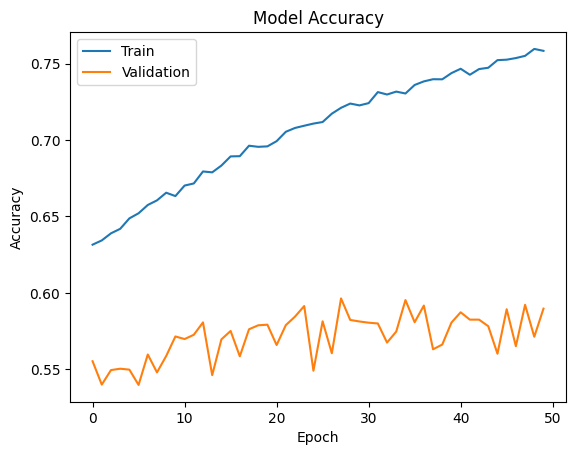

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
cifar100_classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'coffee_cup', 'computer_keyboard', 'couch', 'crab',
    'crocodile', 'cup', 'dinosaur', 'dolphin', 'dog', 'elephant', 'flatfish',
    'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'lamp', 'lawn_mower',
    'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle',
    'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter',
    'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy',
    'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

for i in range(len(cifar100_classes)):
    class_name = cifar100_classes[i]
    print(f"Class {i}: {class_name}")

Class 0: apple
Class 1: aquarium_fish
Class 2: baby
Class 3: bear
Class 4: beaver
Class 5: bed
Class 6: bee
Class 7: beetle
Class 8: bicycle
Class 9: bottle
Class 10: bowl
Class 11: boy
Class 12: bridge
Class 13: bus
Class 14: butterfly
Class 15: camel
Class 16: can
Class 17: castle
Class 18: caterpillar
Class 19: cattle
Class 20: chair
Class 21: chimpanzee
Class 22: clock
Class 23: cloud
Class 24: cockroach
Class 25: coffee_cup
Class 26: computer_keyboard
Class 27: couch
Class 28: crab
Class 29: crocodile
Class 30: cup
Class 31: dinosaur
Class 32: dolphin
Class 33: dog
Class 34: elephant
Class 35: flatfish
Class 36: forest
Class 37: fox
Class 38: girl
Class 39: hamster
Class 40: house
Class 41: kangaroo
Class 42: lamp
Class 43: lawn_mower
Class 44: leopard
Class 45: lion
Class 46: lizard
Class 47: lobster
Class 48: man
Class 49: maple_tree
Class 50: motorcycle
Class 51: mountain
Class 52: mouse
Class 53: mushroom
Class 54: oak_tree
Class 55: orange
Class 56: orchid
Class 57: otter
Cla

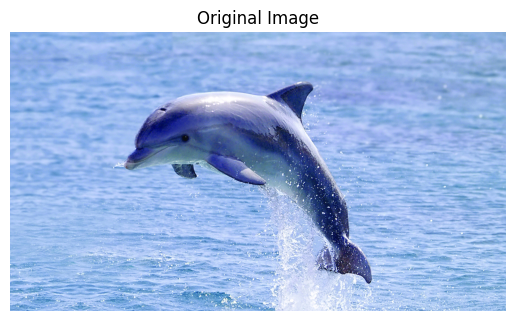

In [ ]:
import cv2
import matplotlib.pyplot as plt
img_cv1=cv2.imread("sample1.jpg")
img_rgb1=cv2.cvtColor(img_cv1,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb1)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [ ]:
# Preprocess the new image for prediction
img_resized1 = cv2.resize(img_rgb1, (32, 32))
img_normalized1 = img_resized1 / 255.0
img_input1 = np.expand_dims(img_normalized1, axis=0) # Add batch dimension

# Predict the class for the new image
predictions1 = model.predict(img_input1)
predicted_class_index1 = np.argmax(predictions1[0])
predicted_class_name1 = cifar100_classes[predicted_class_index1]

print(f"The model predicts the image belongs to class index: {predicted_class_index1}")
print(f"Which corresponds to the class name: {predicted_class_name1}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
The model predicts the image belongs to class index: 45
Which corresponds to the class name: lion
